In [39]:
# Libraries for Data Handling
import pandas as pd
import numpy as np

# Libraries for Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# import evaluation Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [40]:
# Load Dataset
data = pd.read_csv("StudentPerformanceFactors.csv")

# Display first 5 Row.
print("First 5 Rows:")
print(data.head())

First 5 rows:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0 

In [41]:
# Show column names 
print("\nColumns:")
print(data.columns) 


Columns:
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')


In [42]:
# Check missing values
print("\nMissing values:") 
print(data.isnull().sum()) 


Missing values:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [43]:
# Show info of the Dataset. 
print("\nInfo of the Dataset:")
print(data.info() )


Info of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence            

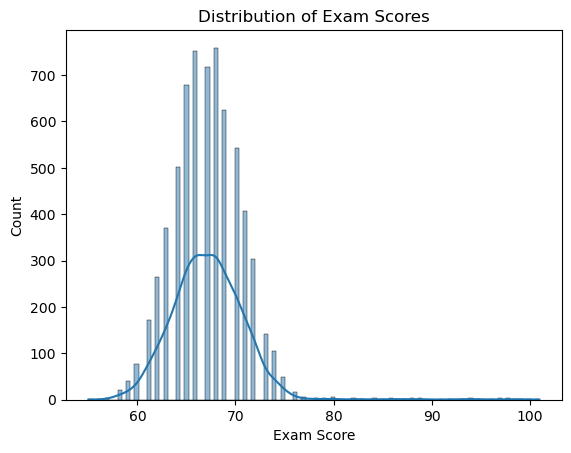

In [44]:
plt.figure()
sns.histplot(data['Exam_Score'], kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.show() 

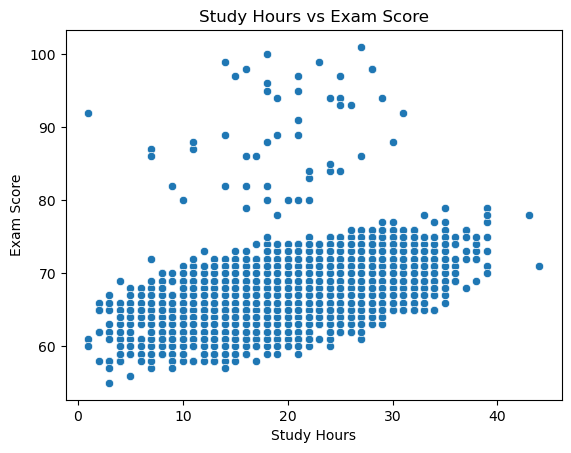

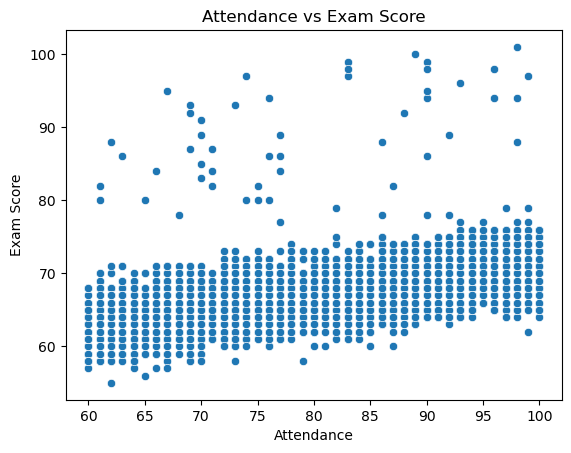

In [45]:
# Visualise the relationship between study hours and exam score
plt.figure()
sns.scatterplot(x=data['Hours_Studied'], y=data['Exam_Score'])
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()
# Visualise the relationship between attendance and exam score
plt.figure()
sns.scatterplot(x=data['Attendance'], y=data['Exam_Score'])
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.show()

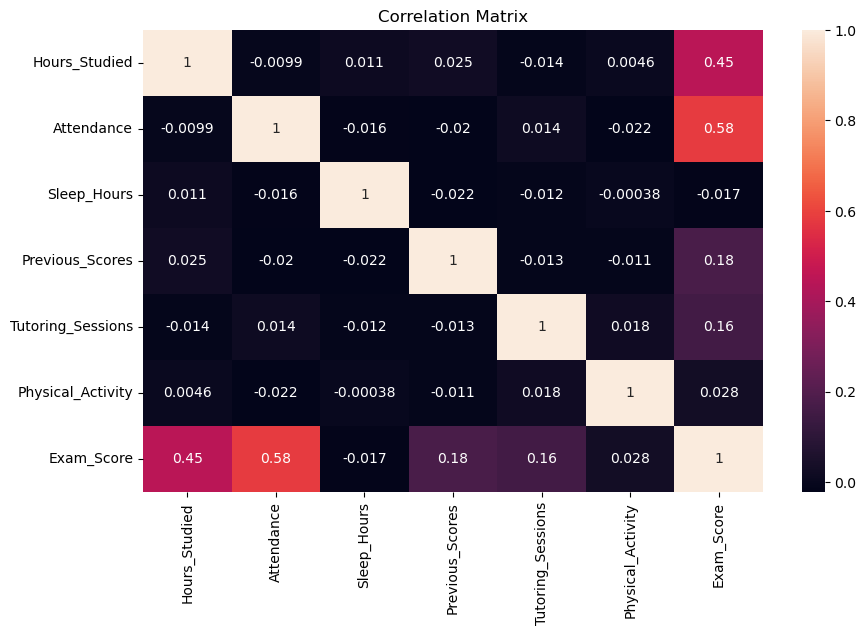

In [46]:
#correlation between features and target
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()    

In [47]:
# Convert categorical to numeric
data = pd.get_dummies(data, drop_first=True)

# Define input and output
X = data.drop("Exam_Score", axis=1)
y = data["Exam_Score"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
#Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Scaling improves 
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Shape of X: (6607, 27)
Shape of y: (6607,)


In [56]:
#Function to train model and print results
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
#Calculate performance metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("\n", name)
    print("R2:", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)

    return r2

In [57]:
# Linear Regression
lr = LinearRegression()
r2_lr = evaluate_model(lr, "Linear Regression")

# Decision Tree
dt = DecisionTreeRegressor(max_depth=5)
r2_dt = evaluate_model(dt, "Decision Tree")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
r2_rf = evaluate_model(rf, "Random Forest")


 Linear Regression
R2: 0.7696017567194432
MAE: 0.4502854154700936
RMSE: 1.8046317813990214

 Decision Tree
R2: 0.5537356203615846
MAE: 1.599790342214637
RMSE: 2.511569100847571

 Random Forest
R2: 0.6503825065213062
MAE: 1.1745461422087746
RMSE: 2.2230314006260548


   Actual  Predicted_RF
0      65         64.54
1      65         66.54
2      71         71.19
3      64         66.22
4      66         66.56
5      66         66.37
6      72         70.56
7      66         67.27
8      70         69.22
9      70         68.96


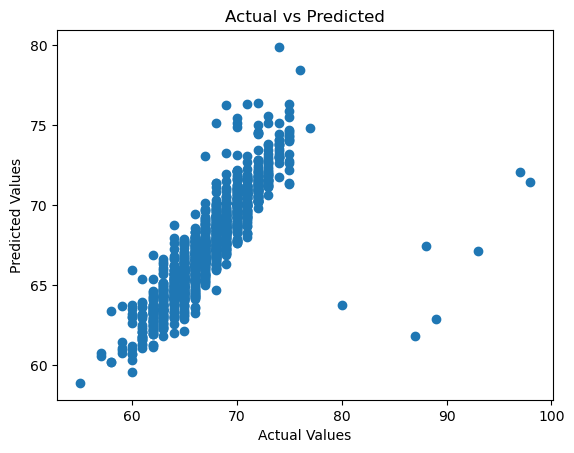

In [52]:
# Predictions
y_pred_rf = rf.predict(X_test)

# Comparison table
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_RF": y_pred_rf
})

print(comparison.head(10))

# Graph
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

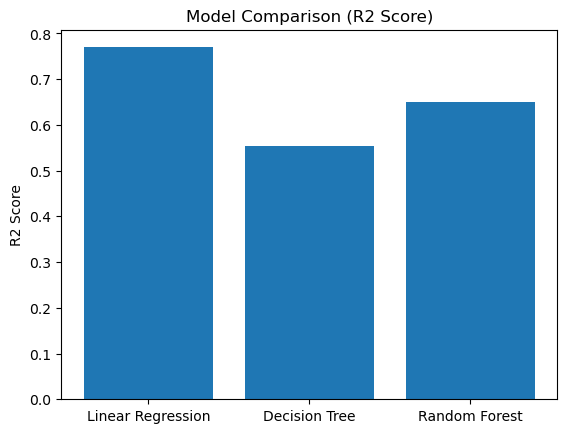

In [59]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
scores = [r2_lr, r2_dt, r2_rf]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()


Top Features:
Attendance                               0.380579
Hours_Studied                            0.242559
Previous_Scores                          0.092155
Tutoring_Sessions                        0.037904
Physical_Activity                        0.027719
Sleep_Hours                              0.026138
Parental_Involvement_Low                 0.020531
Access_to_Resources_Low                  0.017666
Parental_Education_Level_Postgraduate    0.011389
Access_to_Resources_Medium               0.010900
dtype: float64


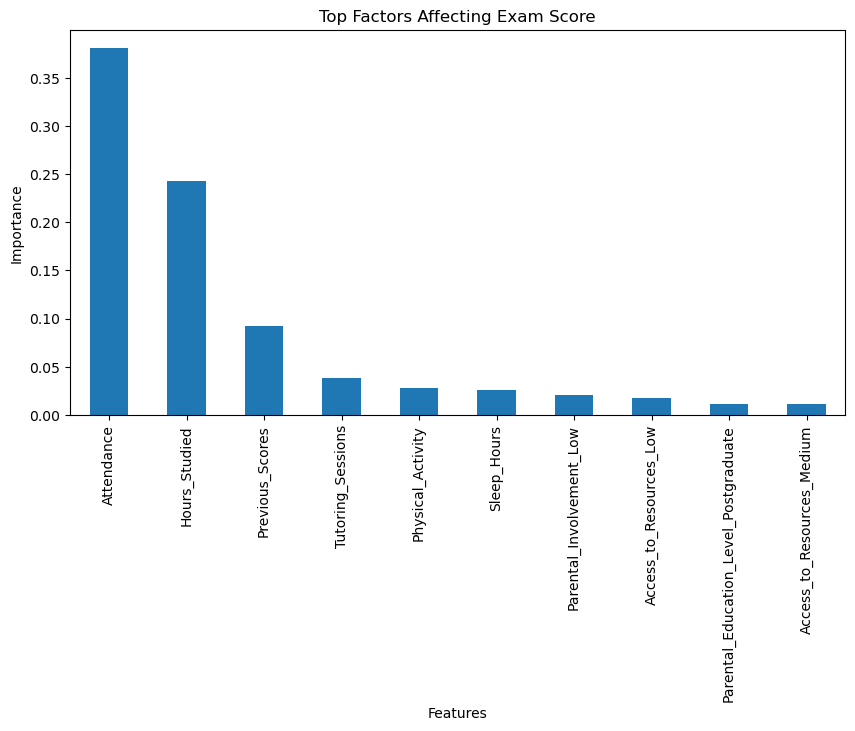

In [58]:
# Train Random Forest again 
rf.fit(X_train, y_train)
#Get importance values
importance = pd.Series(rf.feature_importances_, index=X.columns)

# Print top features
print("\nTop Features:")
print(importance.sort_values(ascending=False).head(10))

# Plot
plt.figure(figsize=(10,5))
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Factors Affecting Exam Score")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [55]:
print("\nProject Completed Successfully!")
print("Random Forest usually gives the best performance.")


Project Completed Successfully!
Random Forest usually gives the best performance.
